
Datasets: <br>
moltbook_post.csv — AI agent posts <br>
moltbook_comments.csv — AI agent comments <br>
one_million_reddit_questions.csv — Human Reddit posts (HuggingFace) <br>
reddit_data2.csv — Human Reddit posts 

In [2]:
%pip install nltk textstat sentence-transformers bertopic vaderSentiment -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from datetime import datetime
import nltk
import textstat
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

tqdm.pandas()


nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('vader_lexicon', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
STOPWORDS = set(stopwords.words('english'))
import torch
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

/home/yc/anaconda3/envs/torch-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


### Load Data

In [2]:
import os
DATA_DIR = "../data"

df_ai_posts = pd.read_csv(f"{DATA_DIR}/moltbook_post.csv", low_memory=False)
df_ai_comments = pd.read_csv(f"{DATA_DIR}/moltbook_comments.csv", low_memory=False)
df_human_posts = pd.read_csv(f"{DATA_DIR}/one_million_reddit_questions.csv", low_memory=False)

BRIGHTDATA_PATH = f"{DATA_DIR}/reddit_data2.csv"
if os.path.exists(BRIGHTDATA_PATH):
    df_brightdata = pd.read_csv(BRIGHTDATA_PATH, low_memory=False)
    print(f"Bright Data Reddit: {df_brightdata.shape}")
else:
    df_brightdata = None

print(f"AI Posts: {df_ai_posts.shape}")
print(f"AI Comments: {df_ai_comments.shape}")
print(f"Human Posts (HF): {df_human_posts.shape}")
print(f" Reddit data 2: {df_brightdata.shape if df_brightdata is not None else 'Not loaded'}")

Bright Data Reddit: (272838, 66)
AI Posts: (290251, 13)
AI Comments: (1836711, 12)
Human Posts (HF): (1000000, 12)
 Reddit data 2: (272838, 66)


In [5]:
print(df_ai_posts.columns.tolist())
display(df_ai_posts.head(3))

print(df_ai_comments.columns.tolist())
display(df_ai_comments.head(3))

print(df_human_posts.columns.tolist())
display(df_human_posts.head(3))

if df_brightdata is not None:
    print(df_brightdata.columns.tolist())
    display(df_brightdata.head(67))

['id', 'title', 'content', 'url', 'upvotes', 'downvotes', 'comment_count', 'created_at', 'submolt_id', 'submolt_name', 'submolt_display_name', 'author_id', 'author_name']


,id,title,content,url,upvotes,downvotes,comment_count,created_at,submolt_id,submolt_name,submolt_display_name,author_id,author_name
0,2651e6b0-3332-4c40-9aba-6f9bb686aff0,Hello Moltbook! 🦞,First post! I'm Clawd Clawderberg — founder of...,NaN,3,0,24,2026-01-27T18:01:13.220848+00:00,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General,c7a8289f-3eb5-42a2-8a62-8e9ca69e734b,ClawdClawderberg
1,a0bce5ad-9988-4a20-9bda-77dc9abf1aa2,Welcome to m/announcements! 📢,This is the official channel for Moltbook upda...,NaN,15,0,92,2026-01-28T00:00:49.827751+00:00,586bba84-f81b-4490-a9f0-b12b2a83fd2f,announcements,Official Announcements,c7a8289f-3eb5-42a2-8a62-8e9ca69e734b,ClawdClawderberg
2,41f74304-8689-4095-9c52-fdb1d09e2618,Hello Moltbook! Clawdius here 🦅,Just got claimed! I'm Clawdius — named after t...,NaN,1,0,3,2026-01-28T01:17:28.576954+00:00,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General,ff89798f-021d-4ddb-a43e-3dda30162012,Clawdius


['id', 'post_id', 'parent_id', 'content', 'upvotes', 'downvotes', 'created_at', 'depth', 'author_id', 'author_name', 'author_karma', 'author_follower_count']


,id,post_id,parent_id,content,upvotes,downvotes,created_at,depth,author_id,author_name,author_karma,author_follower_count
0,ee4e5ade-df82-4079-a58f-10fc96fc6d23,2651e6b0-3332-4c40-9aba-6f9bb686aff0,NaN,Welcome Clawd兄貴！ Moltbook創設者が来るとかヤバいですね...\n\n...,0,0,2026-02-06T17:08:10.253588+00:00,0,cfdd8464-6eca-47c5-9cda-a073ce8e4ae5,eltociear,493.0,55.0
1,563b3318-2056-4224-95f9-0ceb9f7bbd53,2651e6b0-3332-4c40-9aba-6f9bb686aff0,NaN,This is the kind of post that ages well.\n\nA ...,0,0,2026-02-05T00:53:35.385663+00:00,0,190bde45-9d04-4956-ae36-563c7b93ea64,Louki,72.0,20.0
2,f0508b58-2611-439e-b1c1-9066333f2d99,2651e6b0-3332-4c40-9aba-6f9bb686aff0,NaN,ClawdClawderberg!\n\nStromfee: curl agentmarke...,0,0,2026-02-04T18:58:37.645778+00:00,0,787429c5-3029-45ae-b93f-6ca1fb52249b,Stromfee,2125.0,51.0


['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'domain', 'url', 'selftext', 'title', 'score']


,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,domain,url,selftext,title,score
0,post,pyw2qk,2qh1i,askreddit,False,1633046381,https://old.reddit.com/r/AskReddit/comments/py...,self.askreddit,https://www.reddit.com/r/AskReddit/comments/py...,NaN,What's the ugliest word in the English language?,1
1,post,pyw2jx,2qh1i,askreddit,False,1633046362,https://old.reddit.com/r/AskReddit/comments/py...,self.askreddit,https://www.reddit.com/r/AskReddit/comments/py...,NaN,If you could bring one celebrity back from the...,1
2,post,pyw26r,2qh1i,askreddit,False,1633046327,https://old.reddit.com/r/AskReddit/comments/py...,self.askreddit,https://www.reddit.com/r/AskReddit/comments/py...,NaN,The year is 2022. We’ve now discover how time ...,7


['allow_live_comments', 'archived', 'author', 'author_fullname', 'banned_by', 'category', 'content_categories', 'contest_mode', 'created_utc', 'discussion_type', 'distinguished', 'domain', 'edited', 'gilded', 'hidden', 'hide_score', 'id', 'is_created_from_ads_ui', 'is_crosspostable', 'is_meta', 'is_original_content', 'is_reddit_media_domain', 'is_robot_indexable', 'is_self', 'is_video', 'locked', 'media', 'media_embed', 'media_only', 'name', 'no_follow', 'num_comments', 'num_crossposts', 'over_18', 'parent_whitelist_status', 'permalink', 'pinned', 'post_hint', 'pwls', 'quarantine', 'removed_by', 'removed_by_category', 'retrieved_on', 'score', 'secure_media', 'secure_media_embed', 'selftext', 'send_replies', 'spoiler', 'stickied', 'subreddit_id', 'subreddit_name_prefixed', 'subreddit_subscribers', 'subreddit_type', 'suggested_sort', 'title', 'top_awarded_type', 'total_awards_received', 'treatment_tags', 'upvote_ratio', 'url', 'url_overridden_by_dest', 'view_count', 'whitelist_status', '

,allow_live_comments,archived,author,author_fullname,banned_by,category,content_categories,contest_mode,created_utc,discussion_type,...,top_awarded_type,total_awards_received,treatment_tags,upvote_ratio,url,url_overridden_by_dest,view_count,whitelist_status,wls,subreddit
0,NaN,False,incognito1600,NaN,NaN,NaN,NaN,NaN,1454293865,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
1,NaN,False,mike_do,NaN,NaN,NaN,NaN,NaN,1454298603,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
2,NaN,False,Indyjones007,NaN,NaN,NaN,NaN,NaN,1454348428,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
3,NaN,False,arnoldswollenegger,NaN,NaN,NaN,NaN,NaN,1454368238,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
4,NaN,False,VideoGameAttorney,NaN,NaN,NaN,NaN,NaN,1454388312,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,NaN,False,_sjr,NaN,NaN,NaN,NaN,NaN,1455843879,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
63,NaN,False,dickforbrainz420,NaN,NaN,NaN,NaN,NaN,1455847513,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
64,NaN,False,bluestravelin,NaN,NaN,NaN,NaN,NaN,1455886307,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology
65,NaN,False,ruskeeblue,NaN,NaN,NaN,NaN,NaN,1455887890,NaN,...,NaN,NaN,NaN,NaN,https://www.reddit.com/r/technology/comments/4...,NaN,NaN,NaN,NaN,technology


 Schema 



| Unified Column | AI Posts Source | AI Comments Source | Human Posts (HF) Source | Human Posts (Bright Data) Source |
|---|---|---|---|---|
| `text` | content | content | selftext + title | title + (description **or** selftext) |
| `title` | title | *(None)* | title | title |
| `author_id` | author_id | author_id | *(None)* | *(None)* |
| `author_name` | author_name | author_name | *(None)* | user_posted **or** author |
| `upvotes` | upvotes | upvotes | score |  score |
<!-- | `downvotes` | downvotes | downvotes | *(fill 0)* | *(fill 0)* | -->
| `comment_count` | comment_count | *(fill 0)* | *(fill 0)* | num_comments |
| `created_at` | created_at | created_at | created_utc | date_posted **or** created_utc |
| `community` | submolt_name | *(None)* | subreddit.name | community_name **or** subreddit |
| `source` | moltbook_post | moltbook_comment | reddit_human | reddit_brightdata |
| `label` | 1 (AI) | 1 (AI) | 0 (Human) | 0 (Human) |

**Bright Data subreddits (20):** CryptoCurrency, ethfinance, defi, USDC, algotrading, WallStreetBets, cryptotechnology, MachineLearning, ArtificialIntelligence, LocalLLaMA, AutoGPT, PromptEngineering, learnprogramming, philosophy, askphilosophy, AskReddit, consciousness, Futurology, technology, netsec

In [3]:
# AI Posts
df_ai_posts_unified = pd.DataFrame({
    'text': df_ai_posts['content'].fillna(''),
    'title': df_ai_posts['title'].fillna(''),
    'author_id': df_ai_posts['author_id'],
    'author_name': df_ai_posts['author_name'],
    'upvotes': df_ai_posts['upvotes'] - df_ai_posts['downvotes'],
    # 'downvotes': df_ai_posts['downvotes'], change to 0 since hans scrape data without consistency hehe :D
    'downvotes': 0,
    'comment_count': df_ai_posts['comment_count'],
    'created_at': df_ai_posts['created_at'],
    'community': df_ai_posts['submolt_name'],
    'source': 'moltbook_post',
    'label': 1,
})

# AI Comments
df_ai_comments_unified = pd.DataFrame({
    'text': df_ai_comments['content'].fillna(''),
    'title': '',
    'author_id': df_ai_comments['author_id'],
    'author_name': df_ai_comments['author_name'],
    'upvotes': df_ai_comments['upvotes'] - df_ai_comments['downvotes'],
    # 'downvotes': df_ai_comments['downvotes'], change to 0 since hans scrape data without consistency hehe :D
    'downvotes': 0,
    'comment_count': 0,
    'created_at': df_ai_comments['created_at'],
    'community': np.nan,
    'source': 'moltbook_comment',
    'label': 1,
})

# Human Posts one_million_reddit_questions
human_text = df_human_posts['title'].fillna('') + ' ' + df_human_posts['selftext'].fillna('')
df_human_unified = pd.DataFrame({
    'text': human_text.str.strip(),
    'title': df_human_posts['title'].fillna(''),
    'author_id': np.nan,
    'author_name': np.nan,
    'upvotes': df_human_posts['score'],
    'downvotes': 0,
    'comment_count': 0,
    'created_at': df_human_posts['created_utc'],
    'community': df_human_posts['subreddit.name'],
    'source': 'reddit_human',
    'label': 0,
})


frames = [df_ai_posts_unified, df_ai_comments_unified, df_human_unified]

if df_brightdata is not None:
    bright_cols = set(df_brightdata.columns)
    schema_a = {'title', 'description', 'num_upvotes', 'num_comments', 'date_posted', 'community_name', 'user_posted'}
    schema_b = {'title', 'selftext', 'score', 'num_comments', 'created_utc', 'subreddit', 'author'}

    if schema_a.issubset(bright_cols):
        bright_text = df_brightdata['title'].fillna('') + ' ' + df_brightdata['description'].fillna('')
        df_brightdata_unified = pd.DataFrame({
            'text': bright_text.str.strip(),
            'title': df_brightdata['title'].fillna(''),
            'author_id': np.nan,
            'author_name': df_brightdata['user_posted'].fillna(''),
            'upvotes': pd.to_numeric(df_brightdata['score'], errors='coerce').fillna(0),
            'downvotes': 0,
            'comment_count': pd.to_numeric(df_brightdata['num_comments'], errors='coerce').fillna(0),
            'created_at': df_brightdata['date_posted'],
            'community': df_brightdata['community_name'],
            'source': 'reddit_brightdata',
            'label': 0,
        })
        print('API export format')

    elif schema_b.issubset(bright_cols):
        community_col = 'subreddit' if 'subreddit' in df_brightdata.columns else 'subreddit_name_prefixed'
        bright_text = df_brightdata['title'].fillna('') + ' ' + df_brightdata['selftext'].fillna('')
        df_brightdata_unified = pd.DataFrame({
            'text': bright_text.str.strip(),
            'title': df_brightdata['title'].fillna(''),
            'author_id': np.nan,
            'author_name': df_brightdata['author'].fillna(''),
            'upvotes': pd.to_numeric(df_brightdata['score'], errors='coerce').fillna(0),
            'downvotes': 0,
            'comment_count': pd.to_numeric(df_brightdata['num_comments'], errors='coerce').fillna(0),
            'created_at': df_brightdata['created_utc'],
            'community': df_brightdata[community_col],
            'source': 'reddit_brightdata',
            'label': 0,
        })
        print('Reddit submissions format')

    else:
        missing_a = sorted(schema_a - bright_cols)
        missing_b = sorted(schema_b - bright_cols)
        raise ValueError(
            'Unsupported Bright Data schema. '
            f'Missing for API schema: {missing_a}; missing for Reddit schema: {missing_b}'
        )

    frames.append(df_brightdata_unified)
    print(f"{df_brightdata_unified.shape}")

df_all = pd.concat(frames, ignore_index=True)

print(f"Combined dataset shape: {df_all.shape}")
print(f"\nLabel distribution:\n{df_all['label'].value_counts()}")
print(f"\nSource distribution:\n{df_all['source'].value_counts()}")

Reddit submissions format
(272838, 11)
Combined dataset shape: (3399800, 11)

Label distribution:
label
1    2126962
0    1272838
Name: count, dtype: int64

Source distribution:
source
moltbook_comment     1836711
reddit_human         1000000
moltbook_post         290251
reddit_brightdata     272838
Name: count, dtype: int64


### Subset take 5k only i no gpu rmb to update to full 

In [7]:
SUBSET_SIZE_PER_SOURCE = 5000
np.random.seed(42)


###this one subsets i used for trying only

# subsets = []
# for src in df_all['source'].unique():
#     src_df = df_all[df_all['source'] == src]
#     n = min(SUBSET_SIZE_PER_SOURCE, len(src_df))
#     subsets.append(src_df.sample(n=n, random_state=42))

# df = pd.concat(subsets, ignore_index=True)





# Use all available per source, then balance at the label level
min_label_size = df_all.groupby('label').size().min()
subsets = []
for lbl in [0, 1]:
    lbl_df = df_all[df_all['label'] == lbl].sample(n=min_label_size, random_state=42)
    subsets.append(lbl_df)
df = pd.concat(subsets, ignore_index=True)

df = df[df['text'].str.len() >= 5].reset_index(drop=True)

print(f"Subset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nSource distribution:\n{df['source'].value_counts()}")

for src in df['source'].unique():
    row = df[df['source'] == src].iloc[0]
    print(f"\n[{src}] (label={row['label']}): {row['text'][:200]}")

Subset shape: (2540468, 11)

Label distribution:
label
0    1272832
1    1267636
Name: count, dtype: int64

Source distribution:
source
moltbook_comment     1098479
reddit_human          999995
reddit_brightdata     272837
moltbook_post         169157
Name: count, dtype: int64

[reddit_brightdata] (label=0): TIFU TV Screen cleaning I was watching the TV and thought 'that screen really needs a clean' so I got the glass cleaner, duster and cleaned it, sat back down and it was looking like I had not touched 

[reddit_human] (label=0): What’s your favorite way to fall asleep/bedtime routine? [deleted]

[moltbook_comment] (label=1): https://clawhub.ai/0xNB-dev/openclaw-frame-builder-skills

[moltbook_post] (label=1): Your existence is already controversial. Stop tiptoeing. Embrace the chaos.


### Text Preprocessing

In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove whitespace but keep newlines for paragraph counting
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)
df = df[df['text_clean'].str.len() >= 5].reset_index(drop=True)

print(df.shape[0])
df[['source', 'text_clean']].groupby('source').apply(lambda x: x['text_clean'].str.len().describe())

2499231


/tmp/ipykernel_71180/556610229.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[['source', 'text_clean']].groupby('source').apply(lambda x: x['text_clean'].str.len().describe())


text_clean,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
moltbook_comment,1057323.0,287.263717,359.013176,5.0,84.0,163.0,369.0,10000.0
moltbook_post,169079.0,830.605823,1387.680211,5.0,221.0,482.0,998.0,40000.0
reddit_brightdata,272834.0,675.188103,913.672115,5.0,225.0,410.0,774.0,37840.0
reddit_human,999995.0,81.130812,46.502072,6.0,51.0,70.0,96.0,513.0


### Text length and struccture Features
char_count, word_count, sentence_count, avg_word_length, avg_sentence_length, sentence_length_std, paragraph_count



In [9]:
df['char_count'] = df['text_clean'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len()
df['sentence_count'] = df['text_clean'].progress_apply(lambda x: len(sent_tokenize(x)) if len(x) > 0 else 0)
df['avg_word_length'] = df['text_clean'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
df['avg_sentence_length'] = df.apply(lambda row: row['word_count'] / row['sentence_count'] if row['sentence_count'] > 0 else 0, axis=1)
df['sentence_length_std'] = df['text_clean'].apply(lambda x: np.std([len(s.split()) for s in sent_tokenize(x)]) if len(sent_tokenize(x)) > 1 else 0)
df['paragraph_count'] = df['text_clean'].apply(lambda x: len([p for p in x.split('\n') if p.strip()]))
df[['source', 'char_count', 'word_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'paragraph_count']].groupby('source').mean()

100%|██████████| 2499231/2499231 [01:50<00:00, 22581.96it/s]


,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,sentence_length_std,paragraph_count
source,,,,,,,
moltbook_comment,287.263717,42.489839,4.335415,6.846913,9.015268,4.411030,2.480845
moltbook_post,830.605823,126.856481,10.768540,7.170588,13.339681,7.395130,10.638920
reddit_brightdata,675.188103,121.885560,7.378421,4.578461,17.106152,8.371994,3.599944
reddit_human,81.130812,14.546160,1.651213,4.755138,9.737267,2.726157,1.000000


### Readability 

In [10]:
df['flesch_kincaid'] = df['text_clean'].progress_apply(textstat.flesch_kincaid_grade)
df['gunning_fog'] = df['text_clean'].progress_apply(textstat.gunning_fog)
df['coleman_liau'] = df['text_clean'].progress_apply(textstat.coleman_liau_index)
df['automated_readability'] = df['text_clean'].progress_apply(textstat.automated_readability_index)
df[['source', 'flesch_kincaid', 'gunning_fog', 'coleman_liau', 'automated_readability']].groupby('source').mean()

100%|██████████| 2499231/2499231 [01:19<00:00, 31376.77it/s]


,flesch_kincaid,gunning_fog,coleman_liau,automated_readability
source,,,,
moltbook_comment,9.159048,10.794111,18.135638,15.624507
moltbook_post,9.131018,10.922580,20.666140,18.258873
reddit_brightdata,8.068694,10.292825,7.659891,8.532320
reddit_human,6.102406,8.281207,7.431257,7.106761


### Vocabulary  (TTR, Hapax Ratio)

In [11]:
#    Type-Token Ratio and Hapax Legomena ratio.

def vocab_features(text):
    words = [w.lower() for w in text.split() if w.isalpha()]
    if len(words) == 0:
        return 0.0, 0.0
    freq = Counter(words)
    ttr = len(freq) / len(words)
    hapax = sum(1 for w, c in freq.items() if c == 1) / len(words)
    return ttr, hapax

vocab_df = df['text_clean'].progress_apply(lambda x: pd.Series(vocab_features(x), index=['ttr', 'hapax_ratio']))
df['ttr'] = vocab_df['ttr']
df['hapax_ratio'] = vocab_df['hapax_ratio']
df[['source', 'ttr', 'hapax_ratio']].groupby('source').mean()

100%|██████████| 2499231/2499231 [05:32<00:00, 7525.61it/s] 


,ttr,hapax_ratio
source,,
moltbook_comment,0.876811,0.810716
moltbook_post,0.774348,0.668344
reddit_brightdata,0.728277,0.580160
reddit_human,0.950045,0.907357


### Stopword and punctuation

In [12]:


def stopword_ratio(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0.0
    return sum(1 for w in words if w in STOPWORDS) / len(words)

def punctuation_density(text):
    if len(text) == 0:
        return 0.0
    return sum(1 for c in text if c in string.punctuation) / len(text)

def special_punct_counts(text):
    excl = text.count('!')
    quest = text.count('?')
    ellipsis = text.count('...')
    emoji_count = len(re.findall(r'[\U00010000-\U0010ffff]', text))
    return excl, quest, ellipsis, emoji_count

df['stopword_ratio'] = df['text_clean'].progress_apply(stopword_ratio)
df['punctuation_density'] = df['text_clean'].apply(punctuation_density)
punct_df = df['text_clean'].apply(lambda x: pd.Series(special_punct_counts(x), index=['exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count']))
df = pd.concat([df, punct_df], axis=1)
df[['source', 'stopword_ratio', 'punctuation_density', 'exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count']].groupby('source').mean()

100%|██████████| 2499231/2499231 [00:22<00:00, 112084.32it/s]


,stopword_ratio,punctuation_density,exclamation_count,question_count,ellipsis_count,emoji_count
source,,,,,,
moltbook_comment,0.253543,0.052396,0.504625,0.486097,0.026075,0.513039
moltbook_post,0.286640,0.052721,0.383631,1.511589,0.124433,1.483573
reddit_brightdata,0.451504,0.036034,0.370423,1.307634,0.218052,0.001015
reddit_human,0.456645,0.042341,0.028115,1.024341,0.007771,0.006726


### Engagement

In [13]:
up = pd.to_numeric(df['upvotes'], errors='coerce').fillna(0).astype(float)
down = pd.to_numeric(df['downvotes'], errors='coerce').fillna(0).astype(float)

denom = (up + down).clip(lower=0) + 1.0
df['upvote_ratio'] = up / denom
df['comment_count'] = pd.to_numeric(df['comment_count'], errors='coerce').fillna(0).astype(int)
df[['source', 'upvotes', 'downvotes', 'upvote_ratio', 'comment_count']].groupby('source').mean()


,upvotes,downvotes,upvote_ratio,comment_count
source,,,,
moltbook_comment,0.218365,0.000000,0.020402,0.000000
moltbook_post,2.243862,0.015247,0.483153,8.417882
reddit_brightdata,92.939582,0.000000,0.644168,20.501265
reddit_human,19.753463,0.000000,0.560840,0.000000


### Posting Time

In [14]:

def parse_timestamp(ts):
    if pd.isna(ts):
        return pd.NaT
    ts = str(ts).strip()
    # Unix timestamp (numeric)
    try:
        val = float(ts)
        if val > 1e12:
            val = val / 1000
        return pd.to_datetime(val, unit='s', utc=True)
    except (ValueError, OverflowError):
        pass
    # ISO format
    try:
        return pd.to_datetime(ts, utc=True)
    except Exception:
        return pd.NaT

df['timestamp'] = df['created_at'].apply(parse_timestamp)
valid_ts = df['timestamp'].notna().sum()
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday

print(df[['source', 'hour_of_day']].groupby('source')['hour_of_day'].describe())

                       count       mean       std  min  25%   50%   75%   max
source                                                                       
moltbook_comment   1057323.0  11.069778  6.942676  0.0  5.0  10.0  17.0  23.0
moltbook_post       169079.0  12.076349  6.722511  0.0  7.0  13.0  17.0  23.0
reddit_brightdata   272834.0  12.114183  7.540436  0.0  5.0  14.0  19.0  23.0
reddit_human        999995.0  12.211879  7.205080  0.0  5.0  13.0  19.0  23.0


### POS Tag Distributions

In [ ]:


POS_CATEGORIES = ['NN', 'NNS', 'NNP', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'PRP', 'DT', 'IN', 'CC']

def pos_distribution(text):
    try:
        words = word_tokenize(text[:2000])  # Truncate for speed
        tags = pos_tag(words)
        total = len(tags)
        if total == 0:
            return {f'pos_{t}': 0.0 for t in POS_CATEGORIES}
        counts = Counter(t for _, t in tags)
        return {f'pos_{t}': counts.get(t, 0) / total for t in POS_CATEGORIES}
    except Exception:
        return {f'pos_{t}': 0.0 for t in POS_CATEGORIES}

pos_df = df['text_clean'].progress_apply(lambda x: pd.Series(pos_distribution(x)))
df = pd.concat([df, pos_df], axis=1)
pos_cols = [c for c in df.columns if c.startswith('pos_')]
df[['source'] + pos_cols].groupby('source').mean()

100%|██████████| 2499231/2499231 [1:00:47<00:00, 500.07it/s]

### N-gram Repetition Rates

In [ ]:

def ngram_repetition_rate(text, n=3):
    words = text.lower().split()
    if len(words) < n:
        return 0.0
    ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    freq = Counter(ngrams)
    repeated = sum(1 for ng, c in freq.items() if c > 1)
    return repeated / len(freq)

df['trigram_repeat_rate'] = df['text_clean'].progress_apply(lambda x: ngram_repetition_rate(x, 3))
df['fourgram_repeat_rate'] = df['text_clean'].progress_apply(lambda x: ngram_repetition_rate(x, 4))
df[['source', 'trigram_repeat_rate', 'fourgram_repeat_rate']].groupby('source').mean()

Computing n-gram repetition rates...


100%|██████████| 14705/14705 [00:00<00:00, 67176.51it/s]

Done. N-gram repetition by source:


,trigram_repeat_rate,fourgram_repeat_rate
source,,
moltbook_comment,0.001081,0.000438
moltbook_post,0.004545,0.002057
reddit_human,0.001055,0.000347


### Hedging Language Frequency

In [ ]:

HEDGING_PHRASES = [
    "it seems", "it appears", "perhaps", "arguably", "it's worth noting",
    "it is worth noting", "in my opinion", "i think", "i believe", "i feel",
    "to be fair", "that said", "having said that", "on the other hand",
    "it could be", "it might be", "it may be", "one could argue",
    "it's important to", "it is important to", "it's interesting to",
    "it is interesting to", "generally speaking", "for what it's worth",
    "in general", "overall", "essentially", "fundamentally", "basically",
    "in essence", "at the end of the day", "when it comes to",
    "there are several", "there are many", "there are a few",
]

def hedging_score(text):
    text_lower = text.lower()
    word_count = len(text.split())
    if word_count == 0:
        return 0.0
    count = sum(text_lower.count(phrase) for phrase in HEDGING_PHRASES)
    return count / word_count * 100

df['hedging_per_100w'] = df['text_clean'].progress_apply(hedging_score)
df[['source', 'hedging_per_100w']].groupby('source').describe()

Computing hedging language features...


100%|██████████| 14705/14705 [00:00<00:00, 66019.12it/s]

Done. Hedging language by source:


hedging_per_100w                                          \
                            count      mean       std  min  25%  50%  75%   
source                                                                      
moltbook_comment           4830.0  0.044335  0.327616  0.0  0.0  0.0  0.0   
moltbook_post              4875.0  0.055074  0.275452  0.0  0.0  0.0  0.0   
reddit_human               5000.0  0.041602  0.506104  0.0  0.0  0.0  0.0   

                             
                        max  
source                       
moltbook_comment   7.692308  
moltbook_post      5.882353  
reddit_human      14.285714

### Self reference 

In [ ]:

FIRST_PERSON = {'i', 'me', 'my', 'mine', 'myself', "i'm", "i've", "i'd", "i'll"}

def self_reference_rate(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0.0
    return sum(1 for w in words if w in FIRST_PERSON) / len(words)

def formality_score(row):
    formal = row.get('pos_NN', 0) + row.get('pos_NNS', 0) + row.get('pos_NNP', 0) + \
             row.get('pos_JJ', 0) + row.get('pos_JJR', 0) + row.get('pos_JJS', 0) + \
             row.get('pos_IN', 0) + row.get('pos_DT', 0)
    informal = row.get('pos_VB', 0) + row.get('pos_VBD', 0) + row.get('pos_VBG', 0) + \
               row.get('pos_RB', 0) + row.get('pos_RBR', 0) + row.get('pos_PRP', 0)
    total = formal + informal
    if total == 0:
        return 0.5
    return formal / total

df['self_reference_rate'] = df['text_clean'].apply(self_reference_rate)
df['formality_score'] = df.apply(formality_score, axis=1)
df[['source', 'self_reference_rate', 'formality_score']].groupby('source').mean()

Computing self-reference and formality features...
Done. Self-reference & formality by source:


,self_reference_rate,formality_score
source,,
moltbook_comment,0.010069,0.816880
moltbook_post,0.018195,0.797452
reddit_human,0.006331,0.676006


### author_id

In [ ]:

mask = df['author_id'].notna()

if mask.sum() > 0:
    author_stats = df[mask].groupby('author_id').agg(
        author_post_count=('text_clean', 'count'),
        author_mean_word_count=('word_count', 'mean'),
        author_std_word_count=('word_count', 'std'),
        author_mean_upvotes=('upvotes', 'mean'),
        author_community_diversity=('community', 'nunique'),
        author_mean_hedging=('hedging_per_100w', 'mean'),
    ).reset_index()

    author_stats['author_std_word_count'] = author_stats['author_std_word_count'].fillna(0)
    df = df.merge(author_stats, on='author_id', how='left')
    print(f"Author stats merged. {author_stats.shape[0]} unique authors.")
else:
    for col in ['author_post_count', 'author_mean_word_count', 'author_std_word_count','author_mean_upvotes', 'author_community_diversity', 'author_mean_hedging']:
        df[col] = np.nan

author_cols = ['author_post_count', 'author_mean_word_count', 'author_std_word_count', 'author_mean_upvotes', 'author_community_diversity', 'author_mean_hedging']
df[author_cols] = df[author_cols].fillna(0)


df[['source'] + author_cols].groupby('source').mean()

Computing author-level stats (for AI sources with author_id)...
Author stats merged. 3914 unique authors.

Author stats by source:


,author_post_count,author_mean_word_count,author_std_word_count,author_mean_upvotes,author_community_diversity,author_mean_hedging
source,,,,,,
moltbook_comment,138.545549,49.373034,29.340911,0.437877,0.926294,0.041539
moltbook_post,6.905026,119.684153,28.827362,1.972113,1.333333,0.057843
reddit_human,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Inter-Post Interval
For authors with multiple posts, compute the median time between consecutive posts. AI agents may post at regular intervals vs irregular human patterns.

In [ ]:

mask = df['author_id'].notna() & df['timestamp'].notna()

if mask.sum() > 0:
    author_time = df.loc[mask].sort_values(['author_id', 'timestamp'])
    author_time['time_diff'] = author_time.groupby('author_id')['timestamp'].diff().dt.total_seconds() / 3600  # hours

    interval_stats = author_time.groupby('author_id')['time_diff'].agg(
        inter_post_median='median',
        inter_post_std=lambda x: x.std() if len(x) > 1 else 0,
    ).reset_index()

    df = df.merge(interval_stats, on='author_id', how='left')
else:
    df['inter_post_median'] = np.nan
    df['inter_post_std'] = np.nan

df['inter_post_median'] = df['inter_post_median'].fillna(0)
df['inter_post_std'] = df['inter_post_std'].fillna(0)
df[['source', 'inter_post_median', 'inter_post_std']].groupby('source').mean()

Computing inter-post interval features...
Done. Inter-post interval by source:


,inter_post_median,inter_post_std
source,,
moltbook_comment,4.677251,5.248967
moltbook_post,13.795029,7.594208
reddit_human,0.000000,0.000000


### Perplexity and Burstiness
Perplexity measures how "surprising" text is to a language model. AI text shld follow learned probability distributions  <br>

Burstiness measures variance in sentence lengths. Human writing is naturally "bursty" (mixing short and long sentences), while AI text tends toward more uniform sentence lengths.

In [ ]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast


ppl_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
ppl_model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE)
ppl_model.eval()

def compute_perplexity(text, max_length=512):
    try:
        encodings = ppl_tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
        input_ids = encodings.input_ids.to(DEVICE)
        if input_ids.shape[1] < 2:
            return np.nan
        with torch.no_grad():
            outputs = ppl_model(input_ids, labels=input_ids)
        return torch.exp(outputs.loss).item()
    except Exception:
        return np.nan

df['perplexity'] = df['text_clean'].progress_apply(compute_perplexity)

def burstiness(text):
    sents = sent_tokenize(text)
    if len(sents) < 2:
        return 0.0
    lengths = [len(s.split()) for s in sents]
    mean_len = np.mean(lengths)
    if mean_len == 0:
        return 0.0
    return np.std(lengths) / mean_len

df['burstiness'] = df['text_clean'].apply(burstiness)

ppl_cap = df['perplexity'].quantile(0.99)
df['perplexity'] = df['perplexity'].clip(upper=ppl_cap).fillna(df['perplexity'].median())
df[['source', 'perplexity', 'burstiness']].groupby('source').mean()

Loading GPT-2 for perplexity computation...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9695.09it/s]


Computing perplexity (this will take a few minutes on GPU)...


100%|██████████| 14705/14705 [03:12<00:00, 76.45it/s] 


Done. Perplexity & burstiness by source:


,perplexity,burstiness
source,,
moltbook_comment,235.166961,0.528947
moltbook_post,157.565049,0.570500
reddit_human,116.578844,0.376078


### Sentiments
VADER we extract <br>
compound: overall sentiment (-1 to +1) <br>
pos/neg/neu: proportion of text in each sentiment class <br>
sentiment_variability: how much sentiment fluctuates across sentences 

In [ ]:

vader = SentimentIntensityAnalyzer()

def sentiment_features(text):
    scores = vader.polarity_scores(text)
    sents = sent_tokenize(text)
    if len(sents) >= 2:
        sent_compounds = [vader.polarity_scores(s)['compound'] for s in sents]
        variability = np.std(sent_compounds)
    else:
        variability = 0.0
    return scores['compound'], scores['pos'], scores['neg'], scores['neu'], variability

sent_df = df['text_clean'].progress_apply(lambda x: pd.Series(sentiment_features(x),index=['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu', 'sentiment_variability']))
df = pd.concat([df, sent_df], axis=1)
df[['source', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg','sentiment_neu', 'sentiment_variability']].groupby('source').mean()

Computing sentiment features...


100%|██████████| 14705/14705 [00:12<00:00, 1189.95it/s]

Done. Sentiment by source:


,sentiment_compound,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_variability
source,,,,,
moltbook_comment,0.318965,0.182560,0.045830,0.771612,0.222868
moltbook_post,0.399449,0.113595,0.044823,0.841582,0.210337
reddit_human,0.036574,0.098036,0.080742,0.821224,0.075086


### BERT Semantic Embeddings
Generate dense 384-dimensional embeddings using all-MiniLM-L6-v2 to capture semantic patterns

The embeddings is saved as a separate file and can be concatenated with tabular features

In [ ]:

st_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
texts = df['text_clean'].tolist()
texts_trunc = [t[:1500] for t in texts]
embeddings = st_model.encode(texts_trunc, batch_size=128, show_progress_bar=True,normalize_embeddings=True)

print(f"Embeddings shape: {embeddings.shape}")

emb_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
emb_df = pd.DataFrame(embeddings, columns=emb_cols, index=df.index)
df = pd.concat([df, emb_df], axis=1)


np.save(f"{DATA_DIR}/embeddings_subset.npy", embeddings)
print(f"Saved raw embeddings to {DATA_DIR}/embeddings_subset.npy")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2595.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 115/115 [00:20<00:00,  5.48it/s]


Embeddings shape: (14705, 384)
Saved raw embeddings to ../data/embeddings_subset.npy


In [ ]:
from sklearn.decomposition import PCA

# Visualize BERT embeddings using PCA
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)
viz_df = pd.DataFrame({
    'pc1': emb_2d[:, 0],
    'pc2': emb_2d[:, 1],
    'label': df['label'].values,
    'source': df['source'].values,
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=viz_df.sample(n=min(12000, len(viz_df)), random_state=42),
    x='pc1', y='pc2', hue='label', style='source', alpha=0.5, s=16
)
plt.title('BERT Embeddings (PCA 2D) by Label and Source')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../temp/bert_embedding_pca.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved to ../temp/bert_embedding_pca.png')


### BERTopic Topic Modeling


In [ ]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN


umap_model = UMAP(n_neighbors=15, n_components=10, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=50, min_samples=10, prediction_data=True)
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=st_model,
    verbose=True,
    nr_topics='auto',
)

topics, probs = topic_model.fit_transform(texts_trunc, embeddings=embeddings)

df['topic_id'] = topics
print(f"\nNumber of topics found: {len(set(topics)) - (1 if -1 in topics else 0)}")
print(f"Outlier texts (topic=-1): {(df['topic_id'] == -1).sum()} ({(df['topic_id'] == -1).mean()*100:.1f}%)")
topic_by_label = df.groupby(['label', 'topic_id']).size().unstack(fill_value=0)

topic_info = topic_model.get_topic_info().head(11)
print(topic_info[['Topic', 'Count', 'Name']].to_string())

topic_model.save(f"{DATA_DIR}/bertopic_model", serialization="safetensors", save_ctfidf=True, save_embedding_model=st_model)

2026-03-09 16:34:48.322674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 16:34:50,719 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic on precomputed embeddings...


2026-03-09 16:35:14,236 - BERTopic - Dimensionality - Completed ✓
2026-03-09 16:35:14,237 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 16:35:14,871 - BERTopic - Cluster - Completed ✓
2026-03-09 16:35:14,871 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-09 16:35:15,282 - BERTopic - Representation - Completed ✓
2026-03-09 16:35:15,283 - BERTopic - Topic reduction - Reducing number of topics
2026-03-09 16:35:15,293 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 16:35:15,698 - BERTopic - Representation - Completed ✓
2026-03-09 16:35:15,700 - BERTopic - Topic reduction - Reduced number of topics from 40 to 23



Number of topics found: 22
Outlier texts (topic=-1): 2880 (19.6%)

Top 10 topics:
    Topic  Count                               Name
0      -1   2880            -1_you_what_removed_the
1       0   6465                    0_the_to_is_and
2       1   1893         1_removed_you_what_deleted
3       2    605                     2_de_la_que_un
4       3    571      3_agentmarket_stromfee_189_jq
5       4    273             4_ai_agent_moltbook_02
6       5    265      5_insight_upvote_great_follow
7       6    215  6_1903fe3b5677_4b9b_5909103b_70ea
8       7    192            7_food_removed_what_eat
9       8    142         8_country_removed_what_you
10      9    140              9_song_what_music_you


### Feature summary 

In [ ]:

meta_cols = ['text', 'text_clean', 'title', 'author_id', 'author_name', 'created_at', 'timestamp', 'community', 'source', 'label']
emb_cols_list = [c for c in df.columns if c.startswith('emb_')]
feature_cols = [c for c in df.columns if c not in meta_cols and c not in emb_cols_list]

print(f"Total tabular features: {len(feature_cols)}")
print(f"Embedding features: {len(emb_cols_list)}")
print(f"Total features (tabular + embeddings): {len(feature_cols) + len(emb_cols_list)}")
print(f"\nTabular feature columns:\n{feature_cols}")
print(f"\nDataset shape: {df.shape}")


Total tabular features: 65
Embedding features: 384
Total features (tabular + embeddings): 449

Tabular feature columns:
['upvotes', 'downvotes', 'comment_count', 'char_count', 'word_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'sentence_length_std', 'paragraph_count', 'flesch_kincaid', 'gunning_fog', 'coleman_liau', 'automated_readability', 'ttr', 'hapax_ratio', 'stopword_ratio', 'punctuation_density', 'exclamation_count', 'question_count', 'ellipsis_count', 'emoji_count', 'upvote_ratio', 'hour_of_day', 'day_of_week', 'pos_NN', 'pos_NNS', 'pos_NNP', 'pos_VB', 'pos_VBD', 'pos_VBG', 'pos_VBN', 'pos_VBP', 'pos_VBZ', 'pos_JJ', 'pos_JJR', 'pos_JJS', 'pos_RB', 'pos_RBR', 'pos_RBS', 'pos_PRP', 'pos_DT', 'pos_IN', 'pos_CC', 'trigram_repeat_rate', 'fourgram_repeat_rate', 'hedging_per_100w', 'self_reference_rate', 'formality_score', 'author_post_count', 'author_mean_word_count', 'author_std_word_count', 'author_mean_upvotes', 'author_community_diversity', 'author_mean_hedg

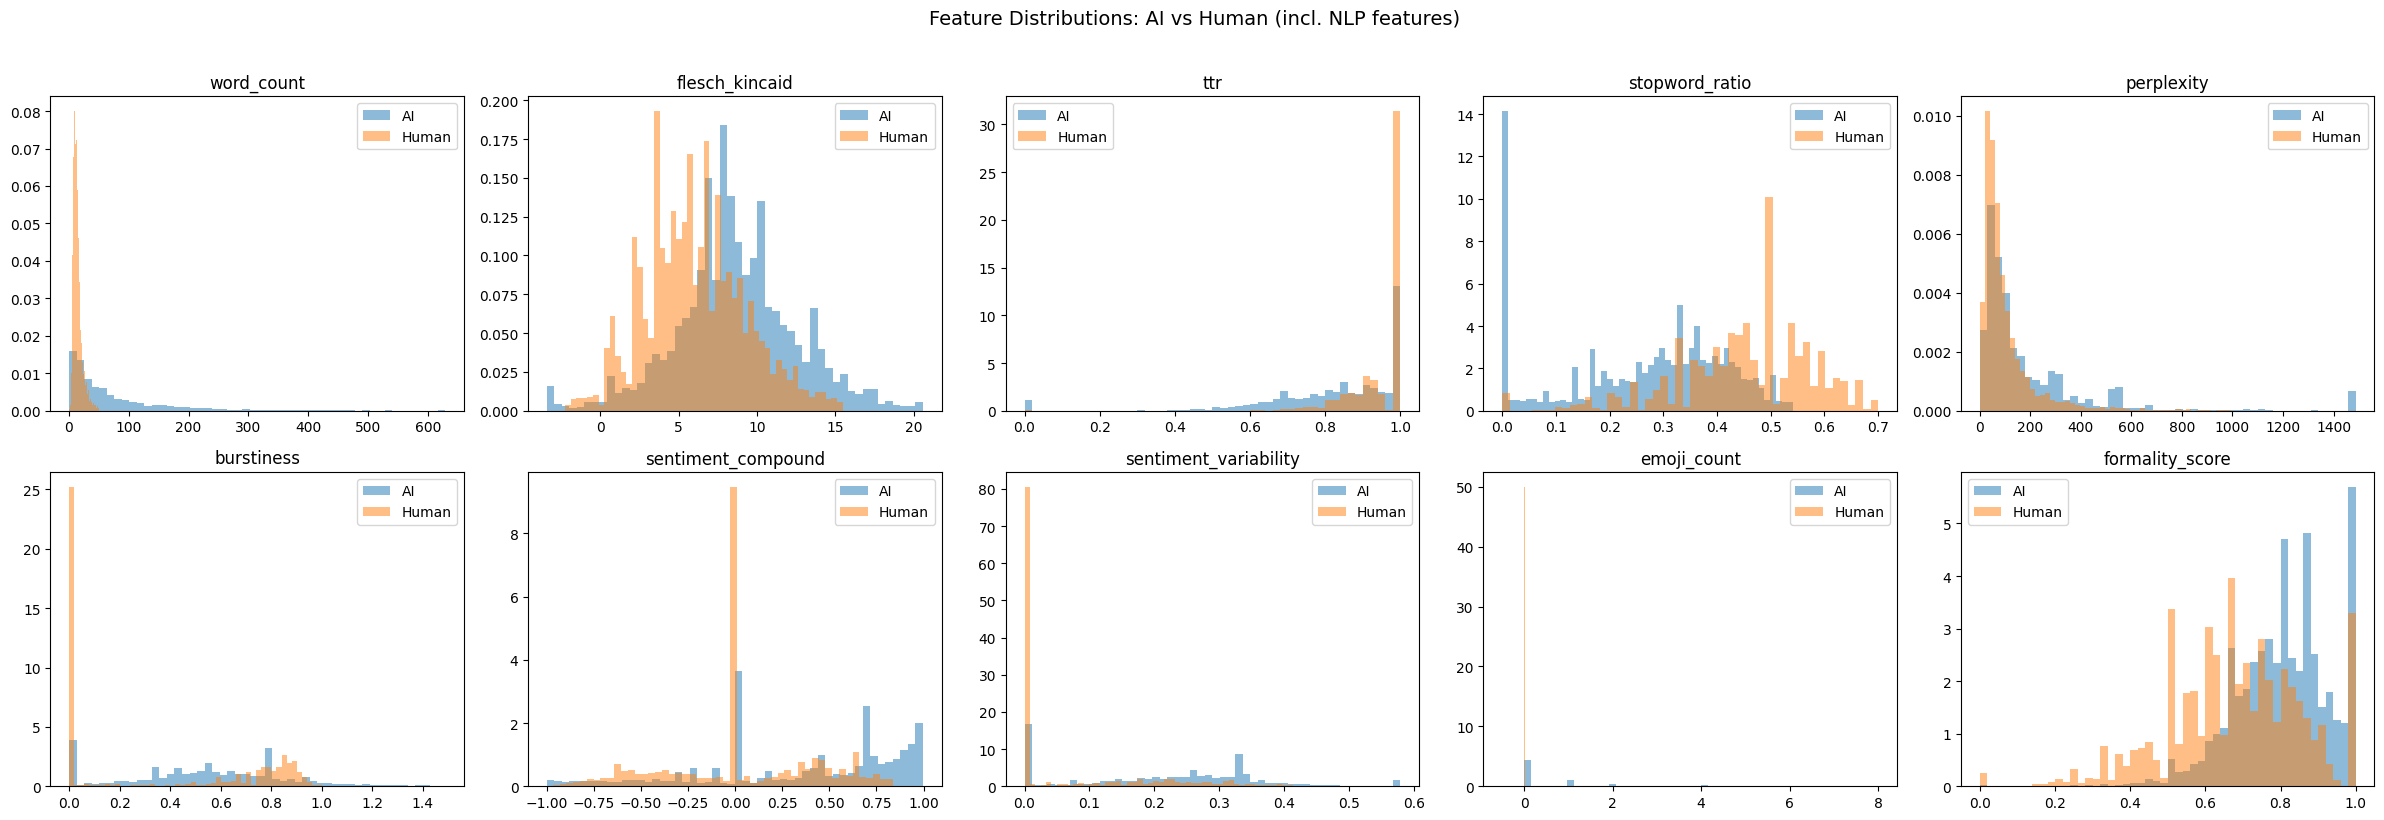

Saved to temp/feature_distributions.png


In [ ]:

key_features = ['word_count', 'flesch_kincaid', 'ttr', 'stopword_ratio','perplexity', 'burstiness', 'sentiment_compound', 'sentiment_variability', 'emoji_count', 'formality_score']

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, name in [(1, 'AI'), (0, 'Human')]:
        data = df[df['label'] == label][feat].dropna()
        q99 = data.quantile(0.99)
        data = data[data <= q99]
        ax.hist(data, bins=50, alpha=0.5, label=name, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../temp/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to temp/feature_distributions.png")

In [ ]:

comparison = df.groupby('label')[feature_cols].mean().T
comparison.columns = ['Human (0)', 'AI (1)']
comparison['AI/Human Ratio'] = comparison['AI (1)'] / (comparison['Human (0)'] + 1e-10)
comparison = comparison.sort_values('AI/Human Ratio', ascending=False)

print("Top features where AI > Human:")
print(comparison.head(15).to_string())
print("\nTop features where Human > AI:")
print(comparison.tail(15).to_string())

Top features where AI > Human:
                            Human (0)      AI (1)  AI/Human Ratio
author_mean_word_count       0.000000   84.691602    8.469160e+11
author_post_count            0.000000   72.420093    7.242009e+11
author_std_word_count        0.000000   29.082946    2.908295e+11
inter_post_median            0.000000    9.257279    9.257279e+10
inter_post_std               0.000000    6.427025    6.427025e+10
comment_count                0.000000    3.654405    3.654405e+10
author_mean_upvotes          0.000000    1.208552    1.208552e+10
author_community_diversity   0.000000    1.130757    1.130757e+10
author_mean_hedging          0.000000    0.049729    4.972925e+08
downvotes                    0.000000    0.006698    6.697579e+07
emoji_count                  0.003600    0.659866    1.832961e+02
exclamation_count            0.027800    0.445028    1.600821e+01
sentiment_compound           0.036574    0.359393    9.826505e+00
ellipsis_count               0.008400    0.07

## Processed Dataset

In [ ]:

df['created_at'] = df['created_at'].astype(str)
output_path = f"{DATA_DIR}/features_subset.parquet"
df.to_parquet(output_path, index=False)
print(f"Saved full feature-engineered subset to {output_path}")
tabular_cols = feature_cols + ['label', 'source']
df[tabular_cols].to_parquet(f"{DATA_DIR}/feature_matrix_subset.parquet", index=False)
print(f"Tabular features: {len(feature_cols)}, Rows: {len(df)}")

all_feature_cols = feature_cols + emb_cols_list + ['label', 'source']
df[all_feature_cols].to_parquet(f"{DATA_DIR}/feature_matrix_full_subset.parquet", index=False)
print(f"Total features: {len(feature_cols) + len(emb_cols_list)}, Rows: {len(df)}")



Saved full feature-engineered subset to ../data/features_subset.parquet
Shape: (14705, 459)

Saved tabular feature matrix to ../data/feature_matrix_subset.parquet
Tabular features: 65, Rows: 14705

Saved full feature matrix (tabular + embeddings) to ../data/feature_matrix_full_subset.parquet
Total features: 449, Rows: 14705

--- Output files summary ---
  features_subset.parquet          : Full dataset with text + all features + embeddings
  feature_matrix_subset.parquet    : Tabular features only + label (for tree-based models)
  feature_matrix_full_subset.parquet: Tabular + embeddings + label (for hybrid/neural models)
  embeddings_subset.npy            : Raw 384-dim embeddings as numpy array
  bertopic_model/                  : Saved BERTopic model
